In [1]:
import pandas as pd

#### Question 1: Handling Missing Values 

In [2]:
df = pd.read_csv("1.csv")
df = pd.DataFrame(df)
df.head()

,Name,Math,Science,English
0,Ravi,85.0,90.0,NaN
1,Meena,78.0,NaN,88.0
2,John,NaN,85.0,80.0
3,Priya,92.0,88.0,95.0


In [ ]:
print(df.isnull().sum())

Name       0
Math       1
Science    1
English    1
dtype: int64


In [ ]:

df["Math"] = df["Math"].fillna(df["Math"].mean())
df["Science"] = df["Science"].fillna(df["Science"].median())
df["English"] = df["English"].fillna(df["English"].mode())
print("Cleaned DataFrame:")
print(df.head())



Cleaned DataFrame:
    Name  Math  Science  English
0   Ravi  85.0     90.0     80.0
1  Meena  78.0     88.0     88.0
2   John  85.0     85.0     80.0
3  Priya  92.0     88.0     95.0


#### Question 2: Outlier Detection Using IQR 

In [ ]:
df = pd.DataFrame({'values': [25000, 27000, 29000, 31000, 32000, 33000, 100000]})

q1 = df['values'].quantile(0.25)
q3 = df['values'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 = {q1}")
print(f"Q3 ={q3}")
print(f"IQR = {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")

outliers = df[(df['values'] < lower_bound) | (df['values'] > upper_bound)]
print("Outliers:")
print(outliers)


Q1 = 28000.0
Q3 =32500.0
IQR = 4500.0
Lower Bound = 21250.0
Upper Bound = 39250.0
Outliers:
   values
6  100000


#### Question 3: Outlier Detection Using Z-score

In [ ]:
df = pd.DataFrame({'values': [12, 14, 15, 16, 18, 19, 20, 120] })
z_scores = (df['values'] - df['values'].mean()) / df['values'].std(ddof=0) 
outliers = df[z_scores > 2]
print(df['values'].std(ddof=0))
print(outliers)

34.390223901568305
Outliers:
   values
7     120


#### Question 4: Data Type Conversion 

In [ ]:
df = pd.DataFrame({

    "Name" : ["Ravi" , "Meena" , "john"] , 
    "Age" : ["25" , "30" , "28"] ,
    "Salary" : [ 50000 , 60000 , 55000]

})

df["Age"] = pd.to_numeric(df["Age"])
df["Salary"] = df["Salary"].astype(float)
print(df.info()) 


<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    3 non-null      str    
 1   Age     3 non-null      int64  
 2   Salary  3 non-null      float64
dtypes: float64(1), int64(1), str(1)
memory usage: 204.0 bytes
None


#### Question 5: Encoding Categorical Variables 

In [ ]:
df = pd.DataFrame({
    "Name" : ["Ravi" , "Meena" , "john" , "Priya"] , 
    "Department" :[ "IT" , "HR"  , "IT" , "Finance"]
    
})
print(df.head())

    Name Department
0   Ravi         IT
1  Meena         HR
2   john         IT
3  Priya    Finance


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

df["Department"] = label_encoder.fit_transform(df["Department"])
print(df.head())


    Name  Department
0   Ravi           2
1  Meena           1
2   john           2
3  Priya           0


In [ ]:
one_hot_encoded = pd.get_dummies(df["Department"] , prefix="Deptament")
df = pd.concat([df, one_hot_encoded], axis=1) 
df.head()

NameError: name 'pd' is not defined

#### Question 6: Feature Scaling 

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.DataFrame({
    "Value" : [100 , 200 , 300 , 400 , 500]
})
scaler = MinMaxScaler()
scaler1 = StandardScaler() 
df["Value_Scaled"] = scaler.fit_transform(df[["Value"]])
print(df["Value_Scaled"])

df["Value_Standardized"] = scaler1.fit_transform(df[["Value"]])
print(df["Value_Standardized"])


0    0.00
1    0.25
2    0.50
3    0.75
4    1.00
Name: Value_Scaled, dtype: float64
0   -1.414214
1   -0.707107
2    0.000000
3    0.707107
4    1.414214
Name: Value_Standardized, dtype: float64


### Part 2 — Data Visualization & EDA Practice Questions 

#### Question 7: Line Plot Using Matplotlib 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'sales trend')

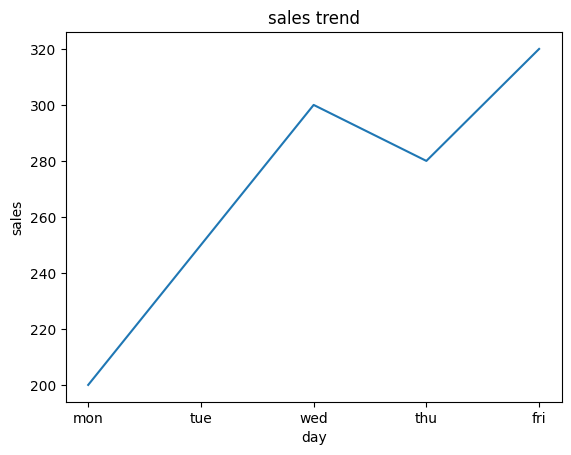

In [ ]:
df = pd.DataFrame({
    "day" :["mon" , "tue" , "wed" , "thu" , "fri"] ,
    "sales" : [200 ,250 , 300 ,280 ,320]
})
sns.lineplot(x="day" , y="sales" , data=df)
plt.title("sales trend")

<Axes: xlabel='Department', ylabel='Employees'>

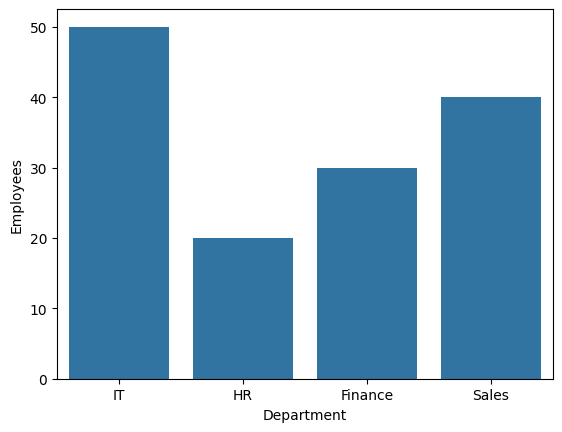

In [ ]:
df = pd.DataFrame({
    "Department" : ["IT" , "HR" , "Finance" , "Sales"] ,
    "Employees" : [50 , 20 , 30 , 40]
})

sns.barplot(x="Department" , y="Employees" , data=df)

<Axes: xlabel='Student_Marks', ylabel='Count'>

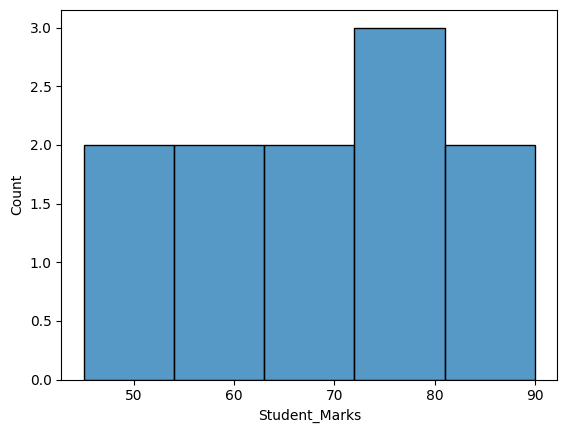

In [ ]:
df = pd.DataFrame({
    "Student_Marks" : [45, 50, 55, 60, 65, 70, 72, 75, 80, 85, 90] 
})

sns.histplot(df["Student_Marks"]  )


#### Question 10: Correlation Matrix Heatmap

             Hours_Study     Sleep    Marks 
Hours_Study     1.000000 -0.943880  0.994377
Sleep          -0.943880  1.000000 -0.903594
Marks           0.994377 -0.903594  1.000000


<Axes: >

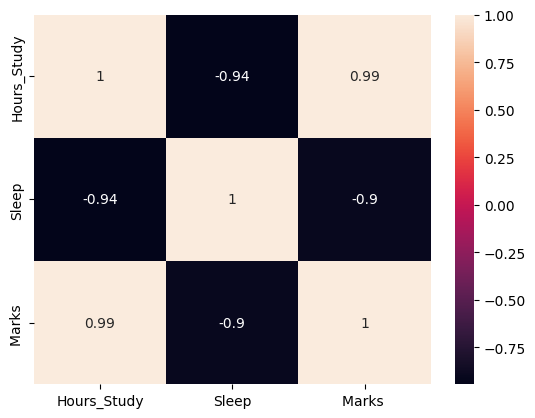

In [ ]:
df = pd.read_csv('10.csv')
df_new = df.corr(method='pearson')
print(df_new)
sns.heatmap(df_new , annot=True)